# MAS DSE 200: Homework 3 - Matplotlib

#### Tasks:

- Introduction to Matplotlib.  
  
- Submission on Gradescope:
  - Submit this Jupyter notebook to "Homework 3"

#### Due date: Thursday, November 6, 2025, 11:59 PM

---

Remember: when in doubt, read the documentation first.

Python - https://docs.python.org/3/

NumPy - https://numpy.org/doc/stable/

pandas - https://pandas.pydata.org/docs/

matplotlib - https://matplotlib.org/stable/contents.html

seaborn - https://seaborn.pydata.org/api.html

## Instructions

* You don’t need to explain your approach (unless specified) so please be concise in your submission.
* To obtain full marks for a question, both the answer and the code should be correct.
* Completely wrong (or missing) code with correct answer will result in zero marks.

### Imports

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import random
import os
import requests
import matplotlib.pyplot as plt
import seaborn as sns

### Preliminaries

Load the cars data into a Pandas DataFrame called cars_df.

In [4]:
thePath = "./"
theFile = 'cars.csv'
theLink = "https://dse200.dev/Day3/cars.csv"

if not os.path.exists(thePath + theFile):
    r = requests.get(theLink)
    with open(thePath + theFile, 'wb') as f:
        f.write(r.content)

cars_df = pd.read_csv('cars.csv')


In [5]:
len(cars_df)

5076

In [6]:
cars_df.head()

,Dimensions.Height,Dimensions.Length,Dimensions.Width,Engine Information.Driveline,Engine Information.Engine Type,Engine Information.Hybrid,Engine Information.Number of Forward Gears,Engine Information.Transmission,Fuel Information.City mpg,Fuel Information.Fuel Type,Fuel Information.Highway mpg,Identification.Classification,Identification.ID,Identification.Make,Identification.Model Year,Identification.Year,Engine Information.Engine Statistics.Horsepower,Engine Information.Engine Statistics.Torque
0,140,143,202,All-wheel drive,Audi 3.2L 6 cylinder 250hp 236ft-lbs,True,6,6 Speed Automatic Select Shift,18,Gasoline,25,Automatic transmission,2009 Audi A3 3.2,Audi,2009 Audi A3,2009,250,236
1,140,143,202,Front-wheel drive,Audi 2.0L 4 cylinder 200 hp 207 ft-lbs Turbo,True,6,6 Speed Automatic Select Shift,22,Gasoline,28,Automatic transmission,2009 Audi A3 2.0 T AT,Audi,2009 Audi A3,2009,200,207
2,140,143,202,Front-wheel drive,Audi 2.0L 4 cylinder 200 hp 207 ft-lbs Turbo,True,6,6 Speed Manual,21,Gasoline,30,Manual transmission,2009 Audi A3 2.0 T,Audi,2009 Audi A3,2009,200,207
3,140,143,202,All-wheel drive,Audi 2.0L 4 cylinder 200 hp 207 ft-lbs Turbo,True,6,6 Speed Automatic Select Shift,21,Gasoline,28,Automatic transmission,2009 Audi A3 2.0 T Quattro,Audi,2009 Audi A3,2009,200,207
4,140,143,202,All-wheel drive,Audi 2.0L 4 cylinder 200 hp 207 ft-lbs Turbo,True,6,6 Speed Automatic Select Shift,21,Gasoline,28,Automatic transmission,2009 Audi A3 2.0 T Quattro,Audi,2009 Audi A3,2009,200,207


### 1. Inspect data - 1 point

1.1 What is the number of unique car identifiers (`Identification.ID`)? - 0.5 points

In [7]:
unique_ids = cars_df['Identification.ID'].nunique()
print(unique_ids)

5030


1.2 What is the number of unique entries in the dataset when jointly looking at `Identification.ID` AND `Identification.Year`? Note that this should be greater than the value obtained before - 0.5 points

In [8]:
unique_ids_and_years = len(cars_df[['Identification.ID', 'Identification.Year']].drop_duplicates())
print(unique_ids_and_years)

5039


In [9]:
assert unique_ids_and_years > unique_ids

### 2. Distribution of data - 3 points
a) Plot a distribution(histogram) of Highway fuel economy(`Fuel Information.Highway mpg`). Overlay this plot with a density plot of the same quantity - 2 points

Note:
1. Each value must have its own bin (Hint - use `range`) and should occupy the entire width of the plot
2. Each bar of the histogram should be blue and separated by black border(Hint - look at `ec` parameter of matplotlib's histogram API)
3. The overlaying density line should be orange

In [10]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt


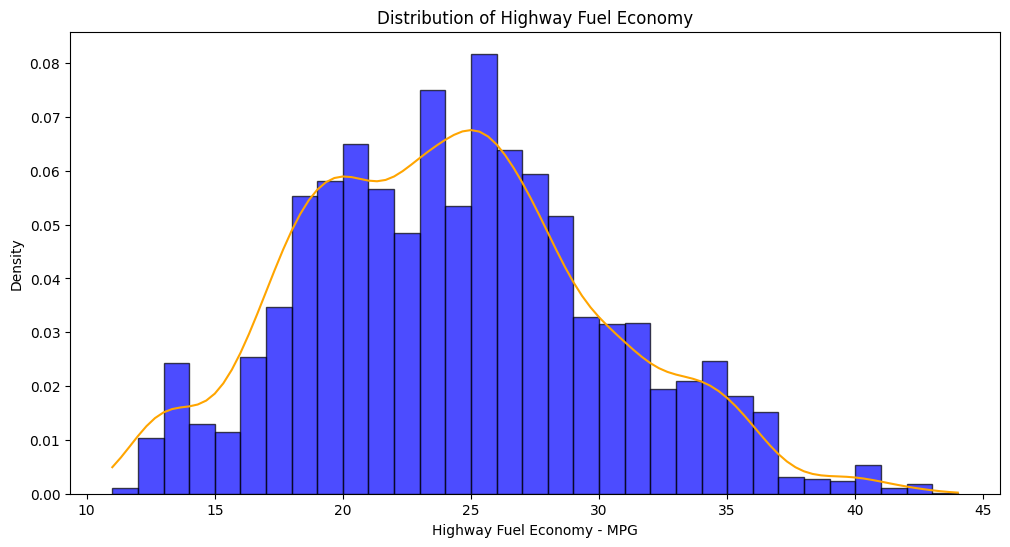

In [11]:
# get data / remove nulls
highway_fuel_economy = cars_df['Fuel Information.Highway mpg'].dropna()

# creates plot
fig, ax = plt.subplots(figsize=(12, 6))

#1 creates bins for each unique value. Used 45 instead of max to get rid of the outlier at 223 mpg and get better visualization of data. 45 is max +1, which I need to do in order to capture last bin.
bins = range(int(highway_fuel_economy.min()), 45)

#2 plot histogram
ax.hist(highway_fuel_economy, bins=bins, color='blue', edgecolor ='black', density=True,alpha=0.7)
ax.set_xlabel('Highway Fuel Economy - MPG')
ax.set_ylabel('Density')
ax.set_title('Distribution of Highway Fuel Economy')

#3 overlay density / orange line. Filtered out outlier as well here, to get more accurate distribution visual. Only need to extend to max data point (44) instead of max+1 like the bin logic above.
density = gaussian_kde(highway_fuel_economy)
x = np.linspace(highway_fuel_economy.min(), 44, 100)
ax.plot(x, density(x), color='orange')
plt.show()

b) Repeate the same for city fuel economy(`Fuel Information.City mpg`) - 0.5 point

(Subjective)(Optional) Is this plot similar to the previous one? Approximately, how much is city fuel economy lower compared to highway fuel economy?

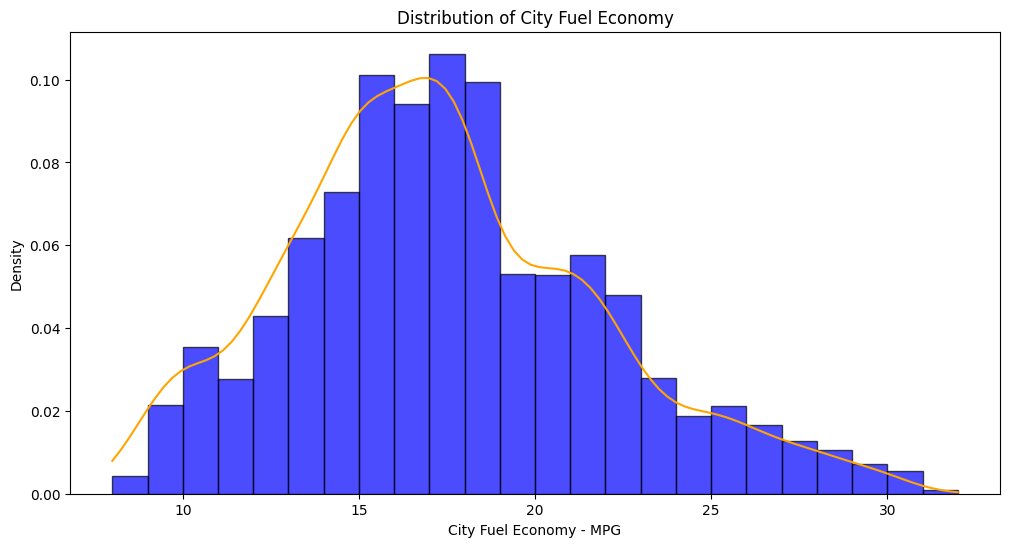

Highway mean: 24.13 mpg
City mean: 17.28 mpg
Difference: 6.85 mpg
City is 6.85 mpg (28.4%) lower than highway


In [12]:
# get data / remove nulls
city_fuel_economy = cars_df['Fuel Information.City mpg'].dropna()

# creates plot
fig, ax = plt.subplots(figsize=(12, 6))

# creates bins for each unique value. Used 33 instead of max to get rid of the outlier at 38 mpg and get better visualization of data. 33 is max +1, which I need to do in order to capture last bin.
bins = range(int(city_fuel_economy.min()), 33)

# plot histogram
ax.hist(city_fuel_economy, bins=bins, color='blue', edgecolor ='black', density=True,alpha=0.7)
ax.set_xlabel('City Fuel Economy - MPG')
ax.set_ylabel('Density')
ax.set_title('Distribution of City Fuel Economy')

# overlay density / orange line. Filtered out outlier as well here, to get more accurate distribution visual. Only need to extend to max data point (32) instead of max+1 like the bin logic above.
density = gaussian_kde(city_fuel_economy)
x = np.linspace(city_fuel_economy.min(), 32, 100)
ax.plot(x, density(x), color='orange')
plt.show()

# Optional question - Both distributions show similar right-skewed shapes, but differ by a little in terms of spread and concentration.
# The highway distribution is a little more spread out, with the majority of values being between 20-30 mpg, while the city distribution has tighter clustering with the majority of values being between 15-20 mpg.
# City fuel economy appears to be approx. 7 mpg lower than highway fuel economy.

# Compare means
highway_mean = highway_fuel_economy.mean()
city_mean = city_fuel_economy.mean()
difference = highway_mean - city_mean

print(f"Highway mean: {highway_mean:.2f} mpg")
print(f"City mean: {city_mean:.2f} mpg")
print(f"Difference: {difference:.2f} mpg")
print(f"City is {difference:.2f} mpg ({(difference/highway_mean)*100:.1f}%) lower than highway")

c) Repeat the same for Engine Horsepower(`Engine Information.Engine Statistics.Horsepower`) - 0.5 points

Note:

1. Use appropriate `bins`, since the range of horsepower is much higher than fuel economy. Hint - Try bin size of `10` or `20`
2. Experiment with different colors from 1 (a)


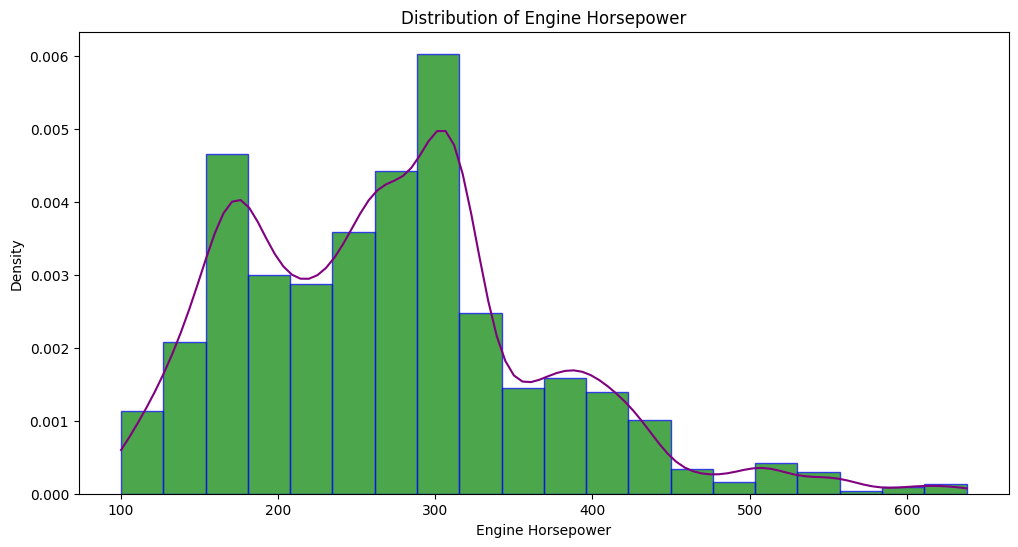

In [13]:
# get data / remove nulls
engine_horsepower = cars_df['Engine Information.Engine Statistics.Horsepower'].dropna()

# creates plot
fig, ax = plt.subplots(figsize=(12, 6))

# plot histogram
ax.hist(engine_horsepower, bins=20, color='green', edgecolor ='blue', density=True,alpha=0.7)
ax.set_xlabel('Engine Horsepower')
ax.set_ylabel('Density')
ax.set_title('Distribution of Engine Horsepower')

# overlay density / orange line
density = gaussian_kde(engine_horsepower)
x = np.linspace(engine_horsepower.min(), engine_horsepower.max(), 100)
ax.plot(x, density(x), color='purple')
plt.show()

### 3. Correlation - 3 points

3.1 Plot a scatter plot, overlayed with a *line of best fit* plot, of engine horsepower vs highway fuel economy - 2 point

* The x-axis is engine power
* The y-axis is fuel economy
* Lable the axes appropriately
* Add an appropriate title
* Use [`np.polyfit`](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) or any other method/library to plot the line of best fit

* Hint - The resulting plot should look similar to [this](https://en.wikipedia.org/wiki/Simple_linear_regression#/media/File:Okuns_law_quarterly_differences.svg)

Reference  -[`Simple linear regression`](https://en.wikipedia.org/wiki/Simple_linear_regression)

You do not have to worry about the details of linear regression here. You can use any library function to do it for you

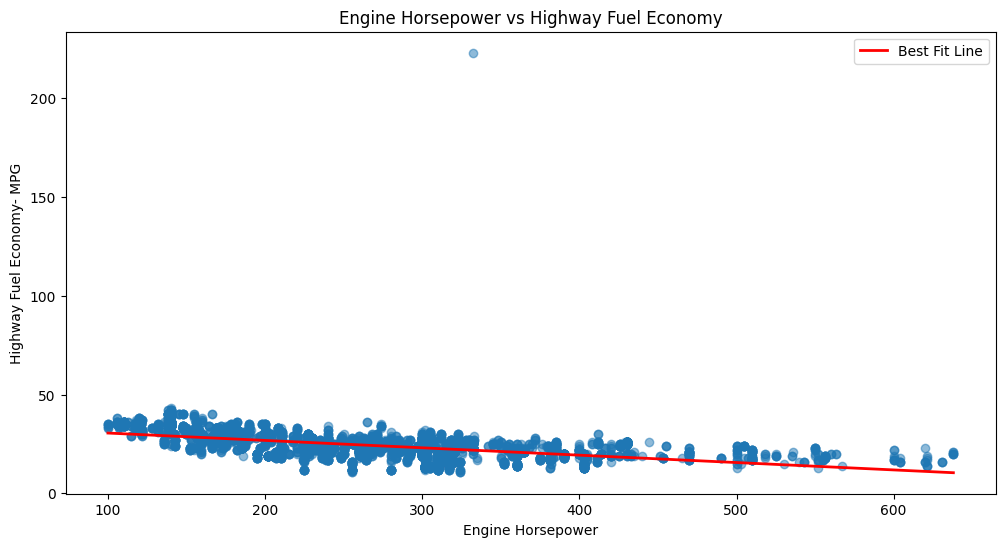

In [14]:
# creates plot
fig, ax = plt.subplots(figsize=(12, 6))

# plot the scatter plot
ax.scatter(engine_horsepower,highway_fuel_economy, alpha=0.5)
ax.set_xlabel('Engine Horsepower')
ax.set_ylabel('Highway Fuel Economy- MPG')
ax.set_title('Engine Horsepower vs Highway Fuel Economy')

# calculate best fit line
best_fit = np.polyfit(engine_horsepower,highway_fuel_economy,1)

# create line --> converts best_fit to a function
line = np.poly1d(best_fit)

#plot the line
x_line = np.linspace(engine_horsepower.min(),engine_horsepower.max(),100)
ax.plot(x_line, line(x_line), color = 'red', linewidth=2, label='Best Fit Line')

ax.legend()
plt.show()

3.2 You might notice in the previous plot that there is an outlier(porbably an error) in fuel economy. Repate the plot after removing the outlier point - 0.5 points

(Optional)(Subjective) What can you tell about the correlation between engine horsepower and fuel economy?

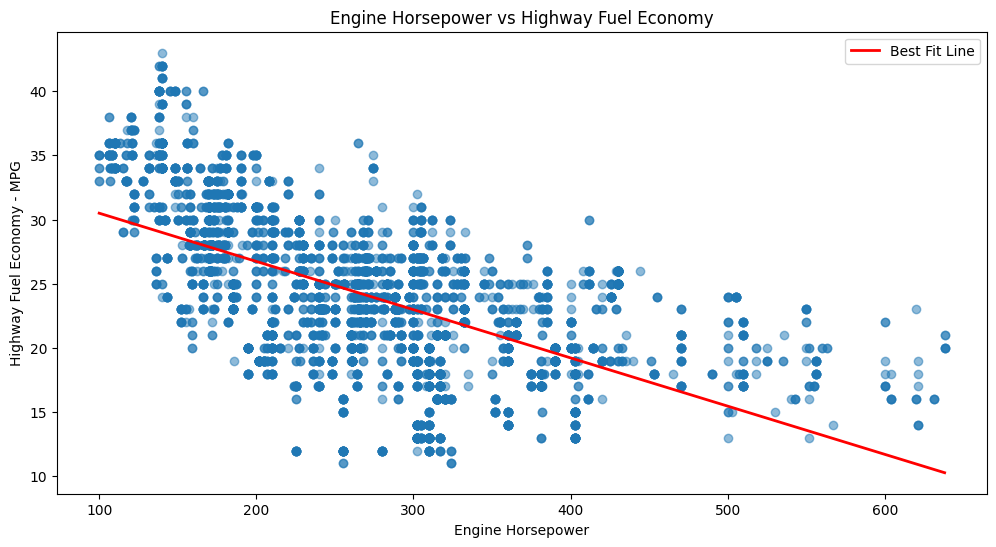

In [15]:
# filter out extreme outlier
scatter_data = cars_df[['Engine Information.Engine Statistics.Horsepower', 'Fuel Information.Highway mpg']].dropna()

# remove outliers over 50 mpg
scatter_data = scatter_data[scatter_data['Fuel Information.Highway mpg'] <= 50]

# extract cleaned columns
engine_horsepower_clean = scatter_data['Engine Information.Engine Statistics.Horsepower']
highway_fuel_economy_clean = scatter_data['Fuel Information.Highway mpg']

# creates plot
fig, ax = plt.subplots(figsize=(12, 6))

# plot the scatter plot
ax.scatter(engine_horsepower_clean,highway_fuel_economy_clean, alpha=0.5)
ax.set_xlabel('Engine Horsepower')
ax.set_ylabel('Highway Fuel Economy - MPG')
ax.set_title('Engine Horsepower vs Highway Fuel Economy')

# calculate best fit line
best_fit = np.polyfit(engine_horsepower_clean,highway_fuel_economy_clean,1)

# create line --> converts best_fit to a function
line = np.poly1d(best_fit)

#plot the line
x_line = np.linspace(engine_horsepower_clean.min(),engine_horsepower_clean.max(),100)
ax.plot(x_line, line(x_line), color = 'red', linewidth=2, label='Best Fit Line')

ax.legend()
plt.show()

# Optional question: (1) As HP increases, fuel economy decreases (2) There is a small correlation between these two factors due to the large amount of scattering around the best fit line (3)

3.3 Repeat the same for engine horsepower(x-axis) and engine torque(y-axis) - 0.5 point

Optional)(Subjective) What can you tell about the correlation between engine horsepower and engine torque?

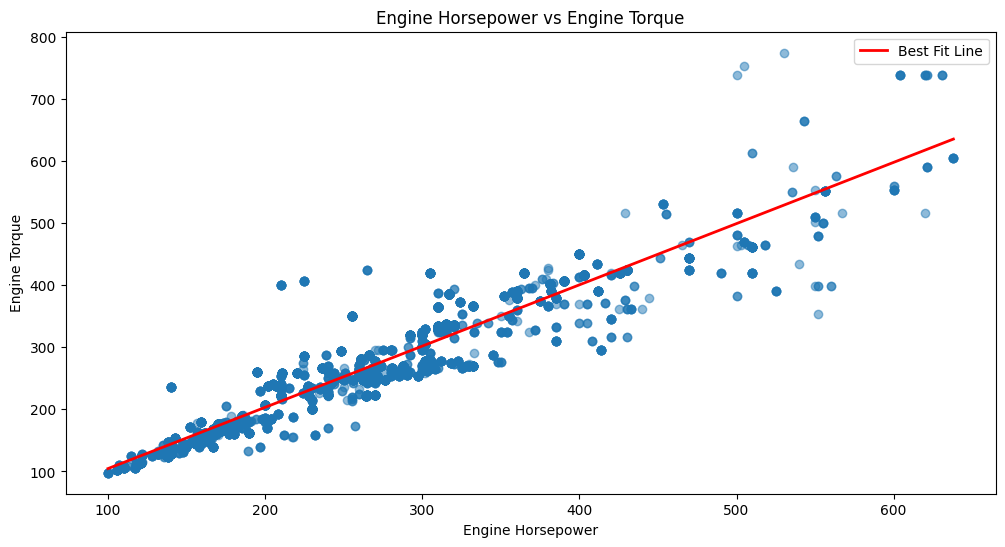

In [16]:
engine_torque = cars_df['Engine Information.Engine Statistics.Torque'].dropna()

# creates plot
fig, ax = plt.subplots(figsize=(12, 6))

# plot the scatter plot
ax.scatter(engine_horsepower,engine_torque, alpha=0.5)
ax.set_xlabel('Engine Horsepower')
ax.set_ylabel('Engine Torque')
ax.set_title('Engine Horsepower vs Engine Torque')

# calculate best fit line
best_fit_2 = np.polyfit(engine_horsepower,engine_torque,1)

# create line --> converts best_fit to a function
line_2 = np.poly1d(best_fit_2)

#plot the line
x_line_2 = np.linspace(engine_horsepower.min(),engine_horsepower.max(),100)
ax.plot(x_line_2, line_2(x_line_2), color = 'red', linewidth=2, label='Best Fit Line')

ax.legend()
plt.show()

# These two variables are much more correlated than the last ones being compared.
# As the engine horsepower increases, so does the torque. Strong positive correlation, tight clustering around best fit line, strong linear relationship.

### 4. Subplots - 3 points

* Create a 2 x 2 subplots of the following plots. Make sure the entire plot is sufficiently large(Hint - check [`rcParams`](https://matplotlib.org/stable/tutorials/introductory/customizing.html) )
    * Box plot of highway fuel economiy(Note the extreme outlier. You may optionally remove it before plotting it. Both are acceptable solutions) - 0.5 points
    * Pie chart of Model year(`Identification.Year`) - 0.5 points
    * Histogram of Length(`Dimensions.Length`) with appropriate bins - 0.5 points
    * Scatter-plot of Length vs Width(`Dimensions.Width`) with marker size representing engine horsepower - 0.5 point
* Subplot and appropriate labelling - 1 point
* The order of the plots does not matter

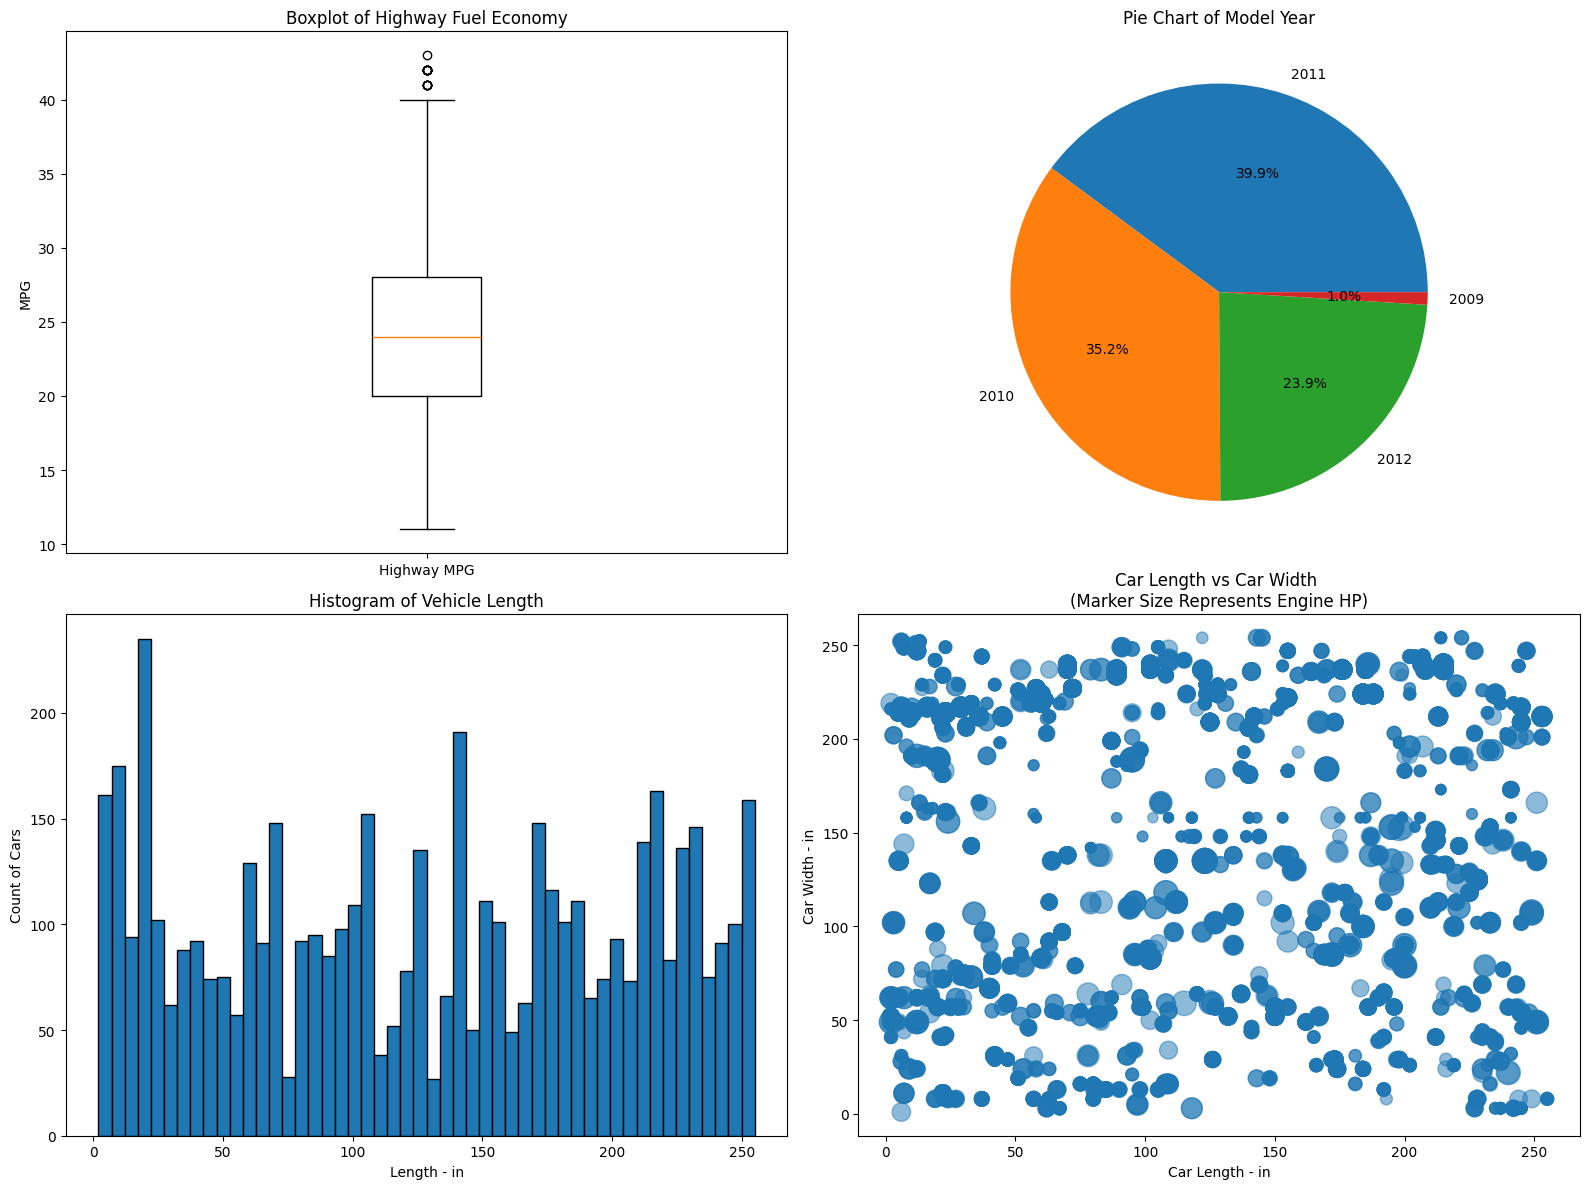

In [17]:
# Make overall figure larger
plt.rcParams['figure.figsize'] = [16, 12]

# Create 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

# Create boxplot of Highway Fuel Economy. Used previously filtered variable that removed outlier
ax1.boxplot(highway_fuel_economy_clean)
ax1.set_title('Boxplot of Highway Fuel Economy')
ax1.set_ylabel('MPG')
ax1.set_xticklabels(['Highway MPG'])

# Create piechart of model year
model_year_counts = cars_df['Identification.Year'].value_counts()
ax2.pie(model_year_counts, labels=model_year_counts.index, autopct='%1.1f%%')
ax2.set_title('Pie Chart of Model Year')

# Create histogram of Length
car_length = cars_df['Dimensions.Length'].dropna()
ax3.hist(car_length, bins=50,  edgecolor ='black')
ax3.set_title('Histogram of Vehicle Length')
ax3.set_xlabel('Length - in')
ax3.set_ylabel('Count of Cars')

# Create scatterplot of length vs width
car_width = cars_df['Dimensions.Width'].dropna()
horsepower = cars_df['Engine Information.Engine Statistics.Horsepower'].dropna()
ax4.scatter(car_length,car_width, s=horsepower/2, alpha=0.5)  # Used horsepower/2 so cars with large HP didn't overshadow other data points visually
ax4.set_xlabel('Car Length - in')
ax4.set_ylabel('Car Width - in')
ax4.set_title('Car Length vs Car Width \n(Marker Size Represents Engine HP)')

plt.tight_layout()
plt.show()

### 5. Heatmap - 3 points

* Create a heatmap of "Make of the car" vs "year+transmission type" for "number of models for that year"
    * Pick the top 8 car manufactutres (`Identification.Make`) by number of cars produced - x-axis
    * Use a combination of model year and transmission type on y-axis.
        * All entries with Automatic transmission should be renamed to "AT" and manual to "MT"
        * Each entry on the Y-axis should look like "2009-AT" representing the model year 2009 and Automatic transmission type
        * This will require some pre-processing with pandas before plotting the heatmap
    * Create a heatmap where each data point shows the number of such models created
    * The heatmap should be of size 8x8, with top 8 manufactutres on x-axis and 8 combinations(4 years and 2 transmission types) of year-transmission on y-axis

['Chevrolet', 'Ford', 'GMC', 'Toyota', 'Nissan', 'Dodge', 'Honda', 'Cadillac']


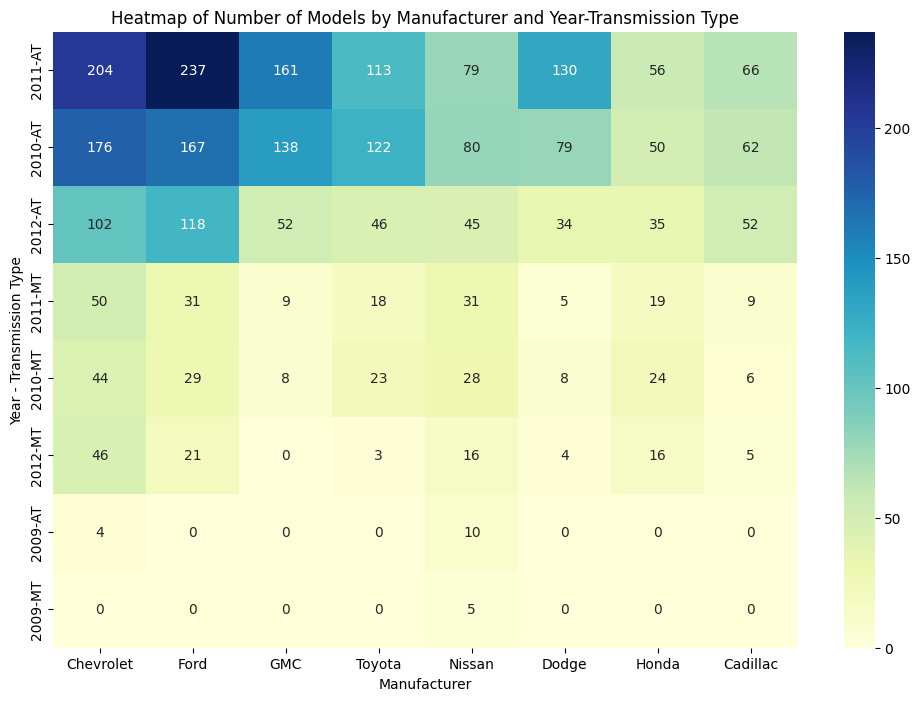

In [43]:
# Count how many cars each manufacturer made, show top 8
top_manufacturers = cars_df['Identification.Make'].value_counts().head(8)

# Get just the Mfg. names as a list
top_8_makes = top_manufacturers.index.tolist()

print(top_8_makes)

# Filter data to only show data tied to top 8
filtered_df = cars_df[cars_df['Identification.Make'].isin(top_8_makes)].copy()

# Create new transmission gruops - AT/MT
def simplify_transmission(trans):
    if 'Automatic' in trans:
        return 'AT'
    elif 'Manual' in trans:
        return 'MT'

# Create new column for AT/MT results
filtered_df['Transmission_Simple'] = filtered_df['Engine Information.Transmission'].apply(simplify_transmission)

# Create new column for year/trans
filtered_df['Year_Trans'] = filtered_df['Identification.Year'].astype(str) + '-' + filtered_df['Transmission_Simple']

# Get top 8 year/trans combos
top_8_years_trans = filtered_df['Year_Trans'].value_counts().head(8).index.tolist()

# Filter down to top 8 combos
filtered_df = filtered_df[filtered_df['Year_Trans'].isin(top_8_years_trans)]

# Create 8x8 grid
heatmap_data = filtered_df.groupby(['Year_Trans','Identification.Make']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.loc[top_8_years_trans,top_8_makes]

# plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True,  fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Number of Models by Manufacturer and Year-Transmission Type')
plt.ylabel('Year - Transmission Type')
plt.xlabel('Manufacturer')
plt.show()

### 6. Pair-plots (Seaborn) - 2 points
* Create a pair-plot of the following columns: length, width, highway fuel economy, city fuel economy, engine power, engine torque
* Which of the pairs show a positive correlation? Which of the pairs show a negative correlation?

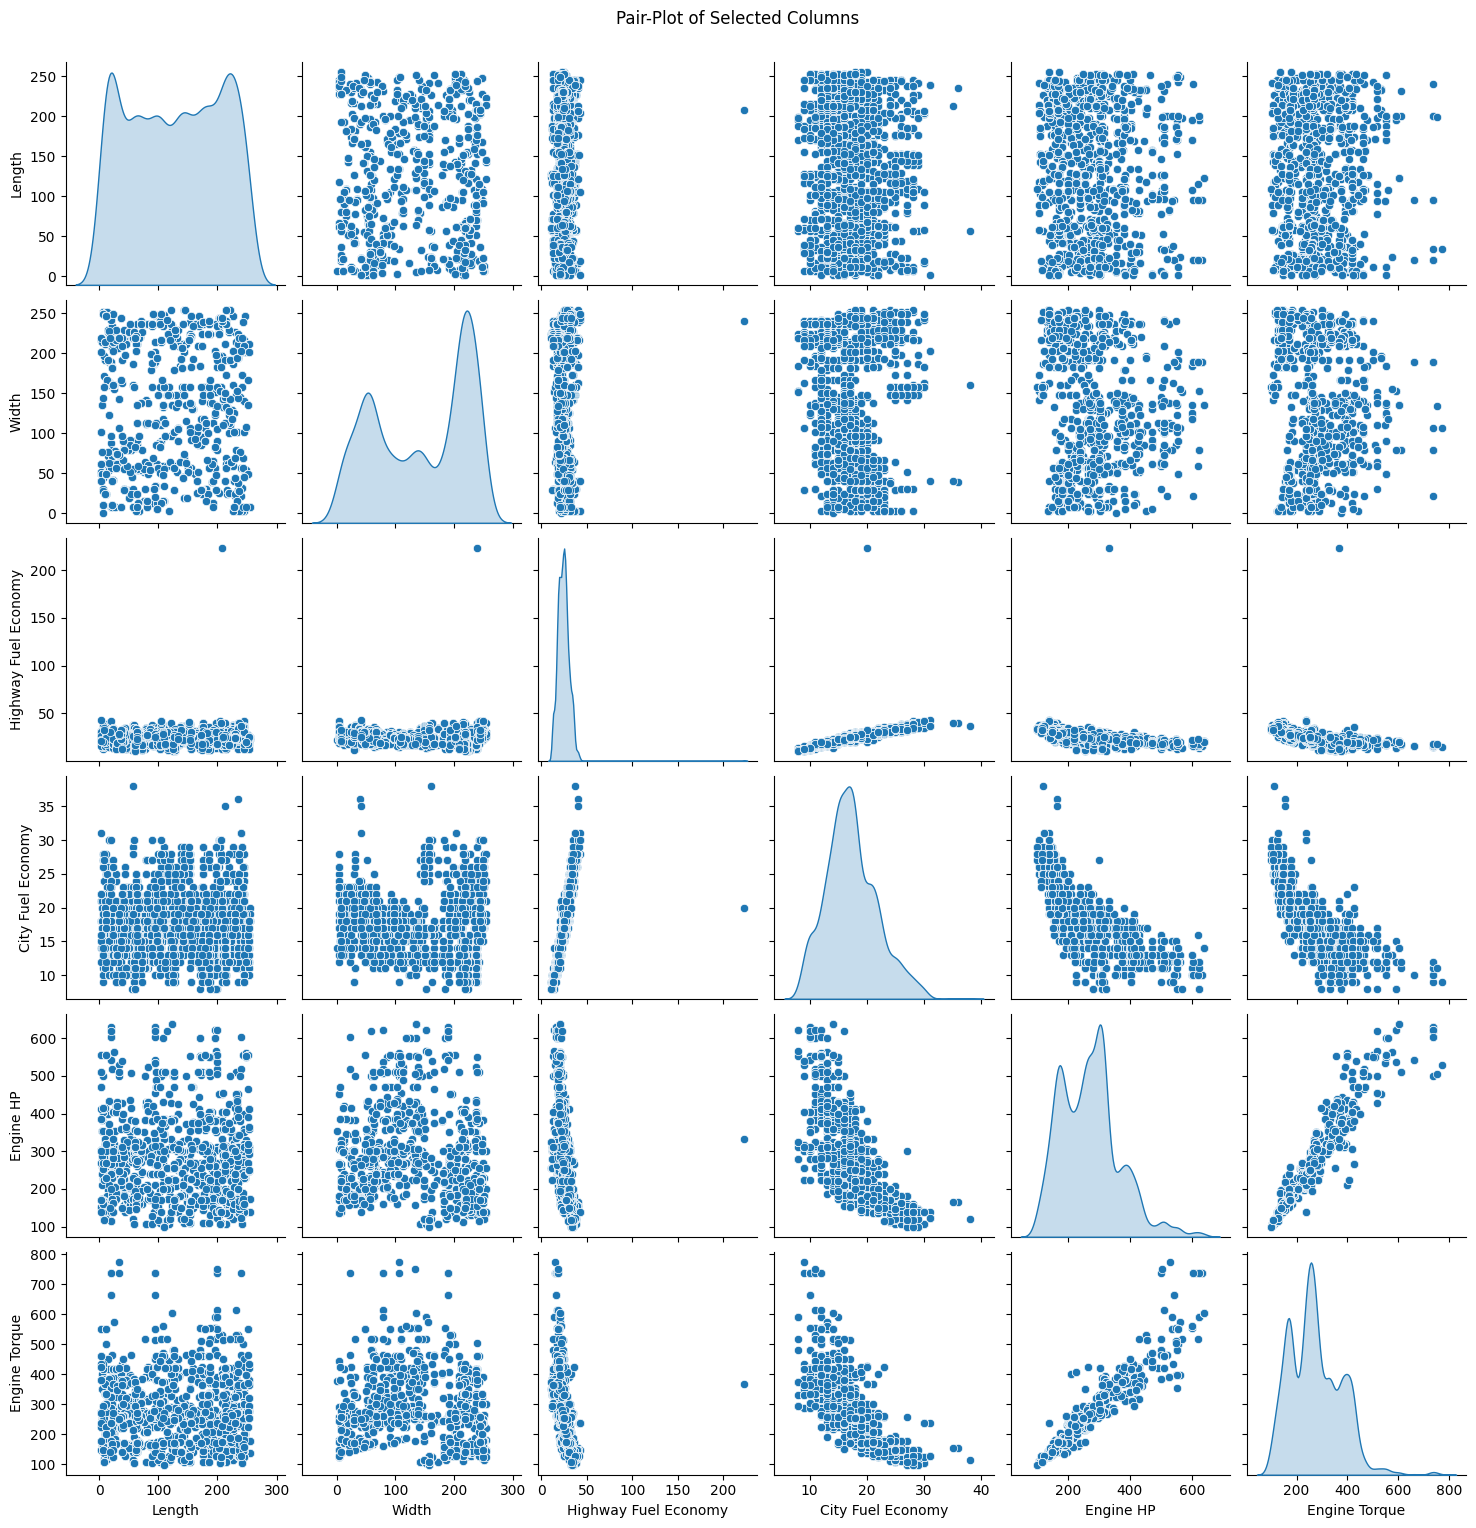

In [51]:
# Create clean dataset w/ selected columns
pairplot_data = cars_df[[
    'Dimensions.Length',
    'Dimensions.Width',
    'Fuel Information.Highway mpg',
    'Fuel Information.City mpg',
    'Engine Information.Engine Statistics.Horsepower',
    'Engine Information.Engine Statistics.Torque']].dropna()

# Rename columns
pairplot_data.columns = ['Length', 'Width', 'Highway Fuel Economy', 'City Fuel Economy', 'Engine HP', 'Engine Torque']

# Create pair-plot
sns.pairplot(pairplot_data, diag_kind='kde')
plt.suptitle('Pair-Plot of Selected Columns', y=1.02)
plt.show()

# Which pairs show positive correlation? Horsepower vs Torque & Highway MPG vs City MPG
# Which pairs show negative correlation? Horsepower/Torque vs Highway/City MPG